# Phase 3: Tabular Exploratory Data Analysis

This notebook describes the full 191,071-row processed dataset and compares it with the reconciled image subset. It contains descriptive statistics and visualizations only; it does not train models.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style='whitegrid', context='notebook')
# notebooks/ is one level below the repository root.
REPOSITORY_ROOT = Path.cwd().resolve()
if not (REPOSITORY_ROOT / 'data').exists():
    REPOSITORY_ROOT = Path.cwd().resolve().parent
FULL_DATA_PATH = REPOSITORY_ROOT / 'data/processed/chexpert_processed.parquet'
SUBSET_DATA_PATH = REPOSITORY_ROOT / 'data/processed/image_subset_manifest.parquet'

df = pd.read_parquet(FULL_DATA_PATH)
subset_df = pd.read_parquet(SUBSET_DATA_PATH)
LABEL_COLUMNS = ['Cardiomegaly_label', 'Edema_label', 'Atelectasis_label', 'Pleural Effusion_label', 'Consolidation_label']
LABEL_NAMES = [column.removesuffix('_label') for column in LABEL_COLUMNS]
print(f'Full dataset: {len(df):,} rows')
print(f'Reconciled image subset: {len(subset_df):,} rows')

Full dataset: 191,071 rows
Reconciled image subset: 12,434 rows


## Section 1: Label Distributions

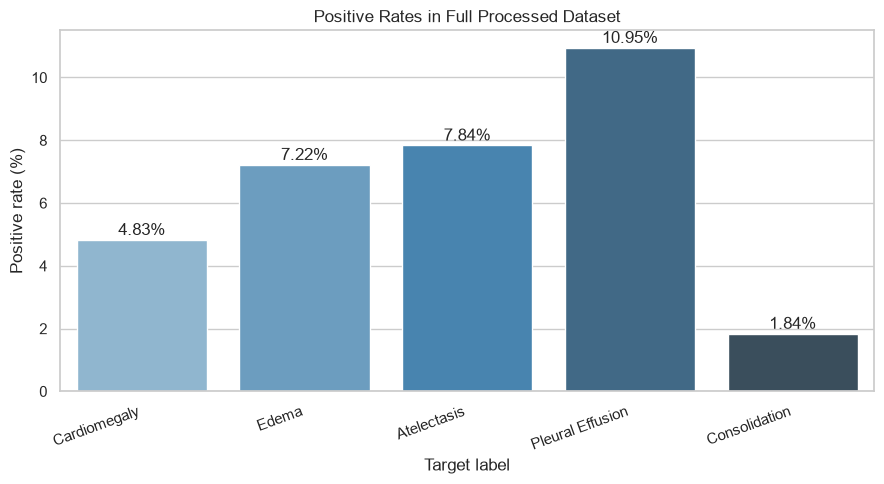

In [2]:
full_rates = df[LABEL_COLUMNS].mean().mul(100)
plt.figure(figsize=(9, 5))
ax = sns.barplot(x=LABEL_NAMES, y=full_rates.values, hue=LABEL_NAMES, palette='Blues_d', legend=False)
ax.set(title='Positive Rates in Full Processed Dataset', xlabel='Target label', ylabel='Positive rate (%)')
plt.xticks(rotation=20, ha='right')
for index, value in enumerate(full_rates.values):
    ax.text(index, value + 0.15, f'{value:.2f}%', ha='center')
plt.tight_layout()
plt.show()

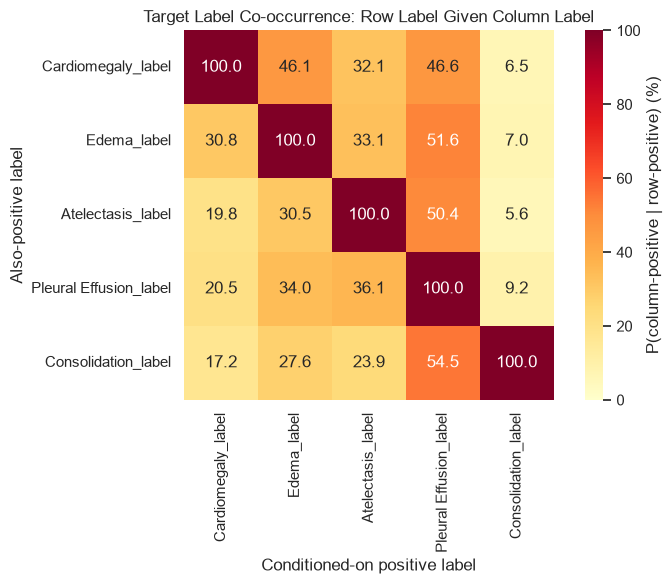

In [3]:
binary_labels = df[LABEL_COLUMNS].astype('int64')
cooccurrence = binary_labels.T.dot(binary_labels).div(binary_labels.sum(axis=0), axis=0).mul(100)
plt.figure(figsize=(8, 6))
sns.heatmap(cooccurrence, annot=True, fmt='.1f', cmap='YlOrRd', vmin=0, vmax=100, square=True, cbar_kws={'label': 'P(column-positive | row-positive) (%)'})
plt.title('Target Label Co-occurrence: Row Label Given Column Label')
plt.xlabel('Conditioned-on positive label')
plt.ylabel('Also-positive label')
plt.tight_layout()
plt.show()

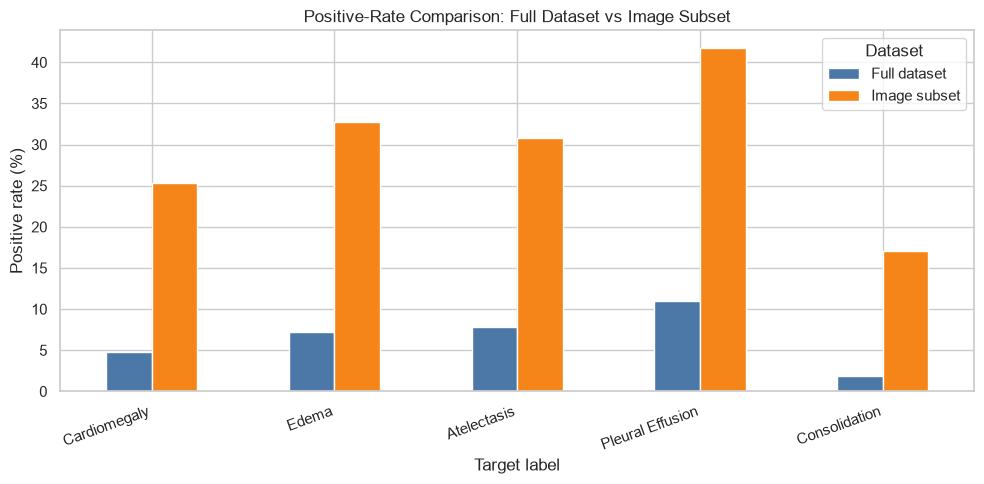

In [4]:
comparison_rates = pd.DataFrame({'Full dataset': df[LABEL_COLUMNS].mean().mul(100), 'Image subset': subset_df[LABEL_COLUMNS].mean().mul(100)}, index=LABEL_COLUMNS)
comparison_rates.index = LABEL_NAMES
ax = comparison_rates.plot(kind='bar', figsize=(10, 5), color=['#4C78A8', '#F58518'])
ax.set(title='Positive-Rate Comparison: Full Dataset vs Image Subset', xlabel='Target label', ylabel='Positive rate (%)')
plt.xticks(rotation=20, ha='right')
plt.legend(title='Dataset')
plt.tight_layout()
plt.show()

**Section 1 summary.** In the full dataset, Pleural Effusion has the highest positive rate (10.95%) and Consolidation the lowest (1.84%). The deliberately enriched 12,434-image subset is much more positive-heavy (e.g., Pleural Effusion 41.78% and Consolidation 17.06%); co-occurrence is strongest between Edema-positive and Pleural-Effusion-positive rows (51.6% of Edema-positive rows are also Pleural-Effusion-positive).

## Section 2: Clinical and Demographic Distributions

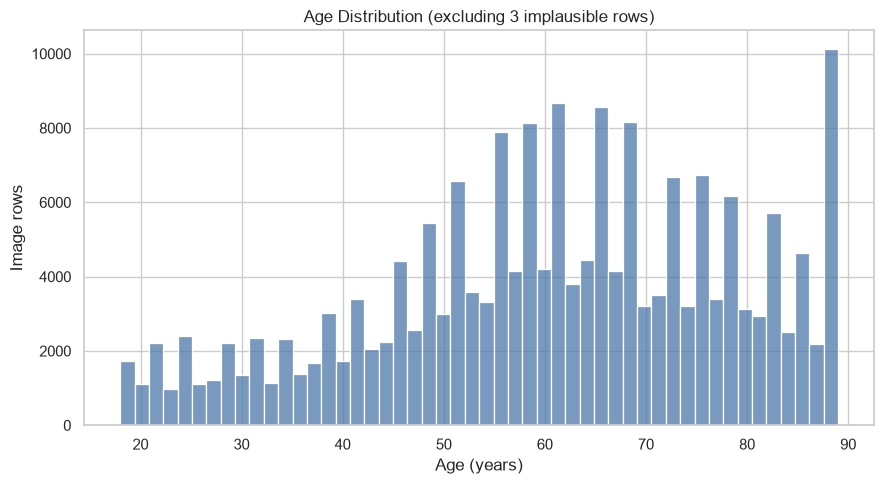

Implausible age rows excluded from histogram: 3


In [5]:
age_implausible_count = int(df['age_implausible'].sum())
valid_age = df.loc[~df['age_implausible'], 'age'].dropna()
plt.figure(figsize=(9, 5))
sns.histplot(valid_age, bins=50, color='#4C78A8')
plt.title(f'Age Distribution (excluding {age_implausible_count} implausible rows)')
plt.xlabel('Age (years)')
plt.ylabel('Image rows')
plt.tight_layout()
plt.show()
print(f'Implausible age rows excluded from histogram: {age_implausible_count:,}')

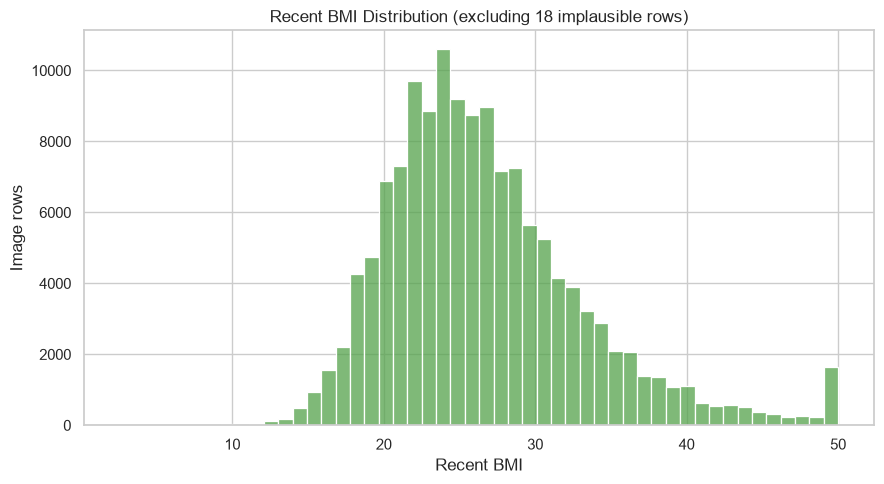

Implausible BMI rows excluded from histogram: 18


In [6]:
bmi_implausible_count = int(df['recent_bmi_implausible'].sum())
valid_bmi = df.loc[~df['recent_bmi_implausible'], 'recent_bmi'].dropna()
plt.figure(figsize=(9, 5))
sns.histplot(valid_bmi, bins=50, color='#54A24B')
plt.title(f'Recent BMI Distribution (excluding {bmi_implausible_count} implausible rows)')
plt.xlabel('Recent BMI')
plt.ylabel('Image rows')
plt.tight_layout()
plt.show()
print(f'Implausible BMI rows excluded from histogram: {bmi_implausible_count:,}')

**BMI missingness.** `recent_bmi` is missing for 52,300 of 191,071 rows (27.37%); the histogram therefore summarizes observed, non-implausible BMI values only.

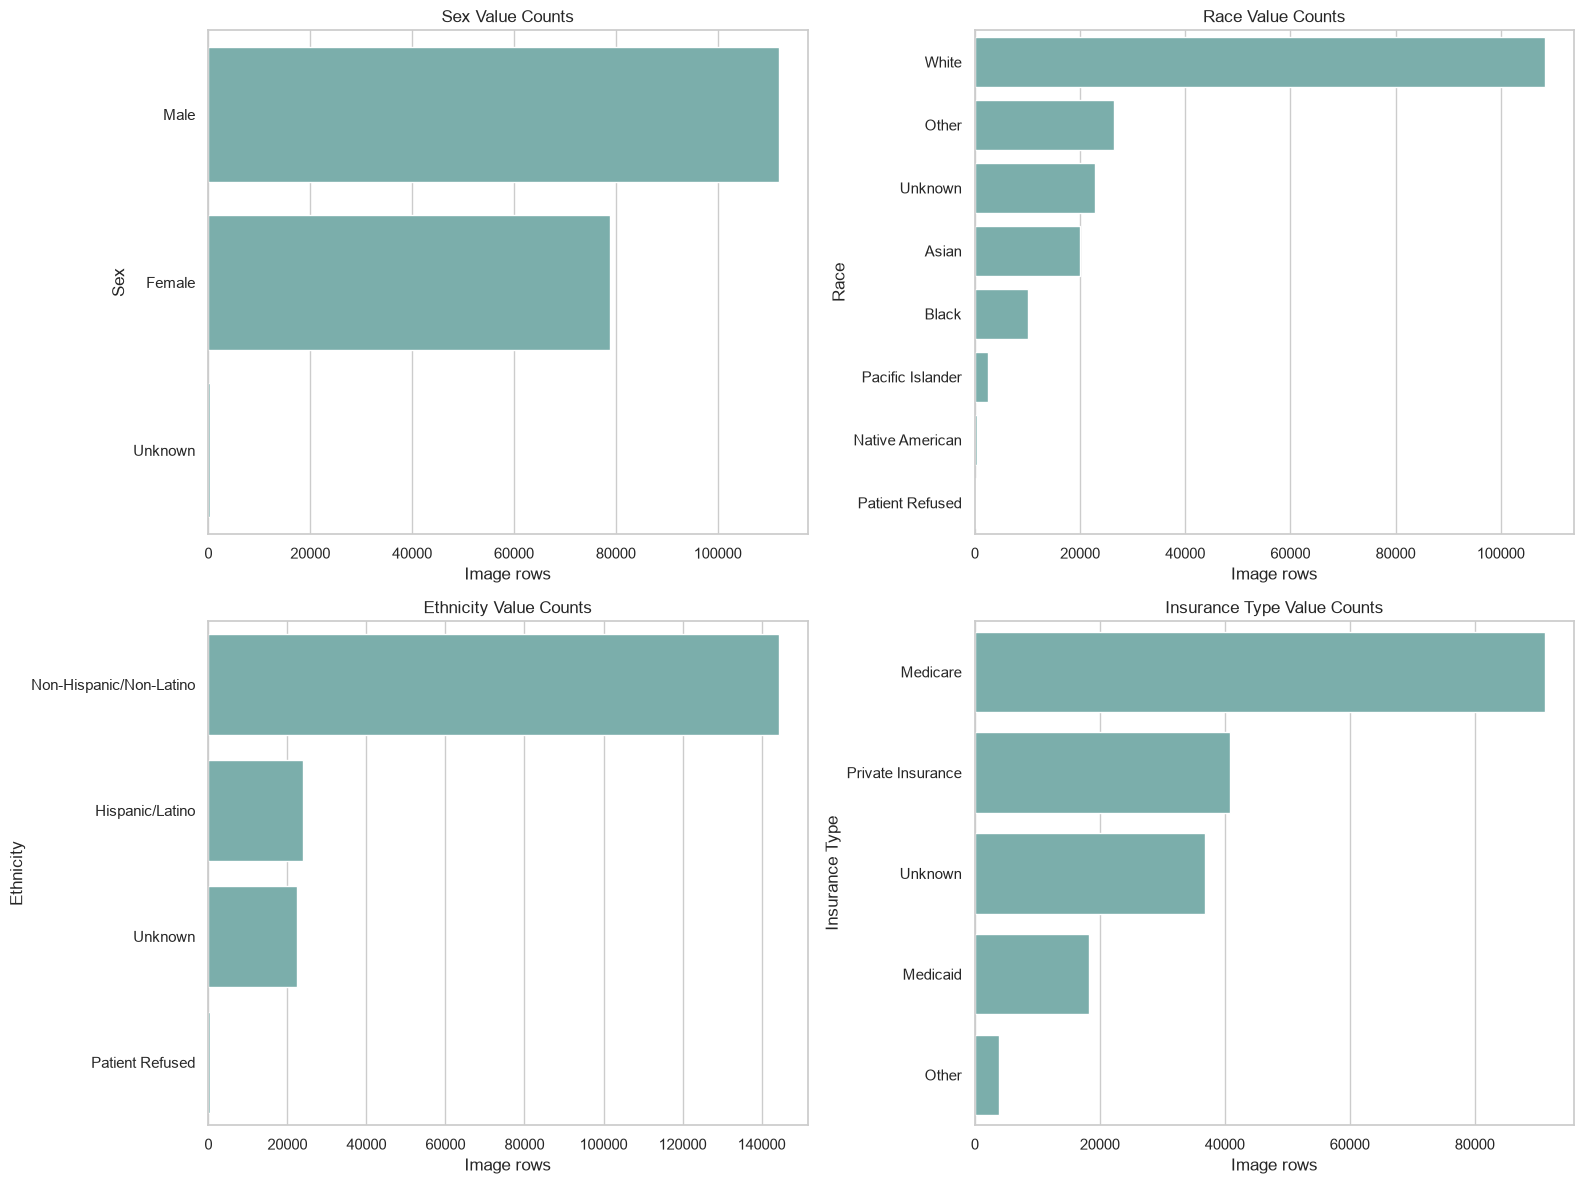

In [7]:
demographic_columns = ['sex', 'race', 'ethnicity', 'insurance_type']
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
for axis, column in zip(axes.flat, demographic_columns):
    counts = df[column].fillna('Missing').value_counts()
    sns.barplot(x=counts.values, y=counts.index, ax=axis, color='#72B7B2')
    axis.set(title=f'{column.replace("_", " ").title()} Value Counts', xlabel='Image rows', ylabel=column.replace('_', ' ').title())
plt.tight_layout()
plt.show()

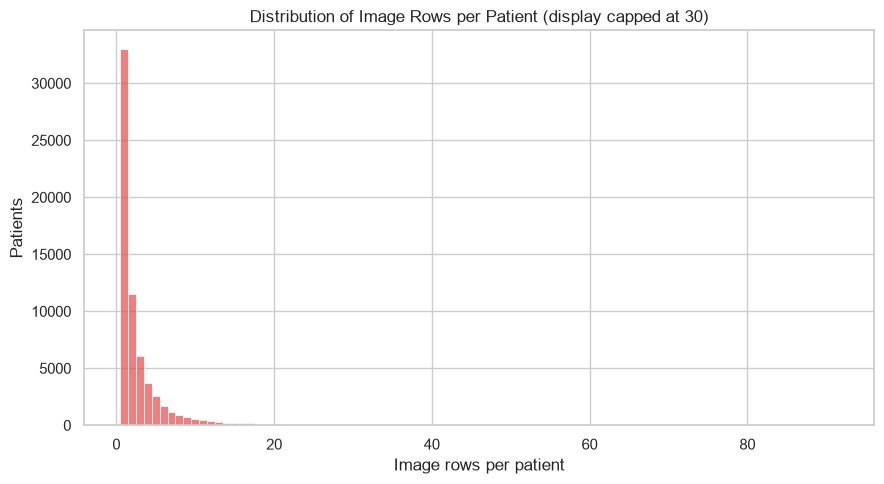

count    64710.000000
mean         2.952728
std          4.241614
min          1.000000
25%          1.000000
50%          1.000000
75%          3.000000
max         91.000000
dtype: float64


In [8]:
studies_per_patient = df.groupby('deid_patient_id').size()
plt.figure(figsize=(9, 5))
sns.histplot(studies_per_patient, bins=range(1, min(int(studies_per_patient.max()), 30) + 2), discrete=True, color='#E45756')
plt.title('Distribution of Image Rows per Patient (display capped at 30)')
plt.xlabel('Image rows per patient')
plt.ylabel('Patients')
plt.tight_layout()
plt.show()
print(studies_per_patient.describe())

**Section 2 summary.** Three rows have implausible ages and 18 have implausible BMI values, so neither issue materially changes the plotted distributions. The dataset contains 64,710 patients with a median of 1 image row per patient (mean 2.95; maximum 91), while 27.37% of BMI values are missing.

## Section 3: Bias Check - Label Rates by Demographic Group

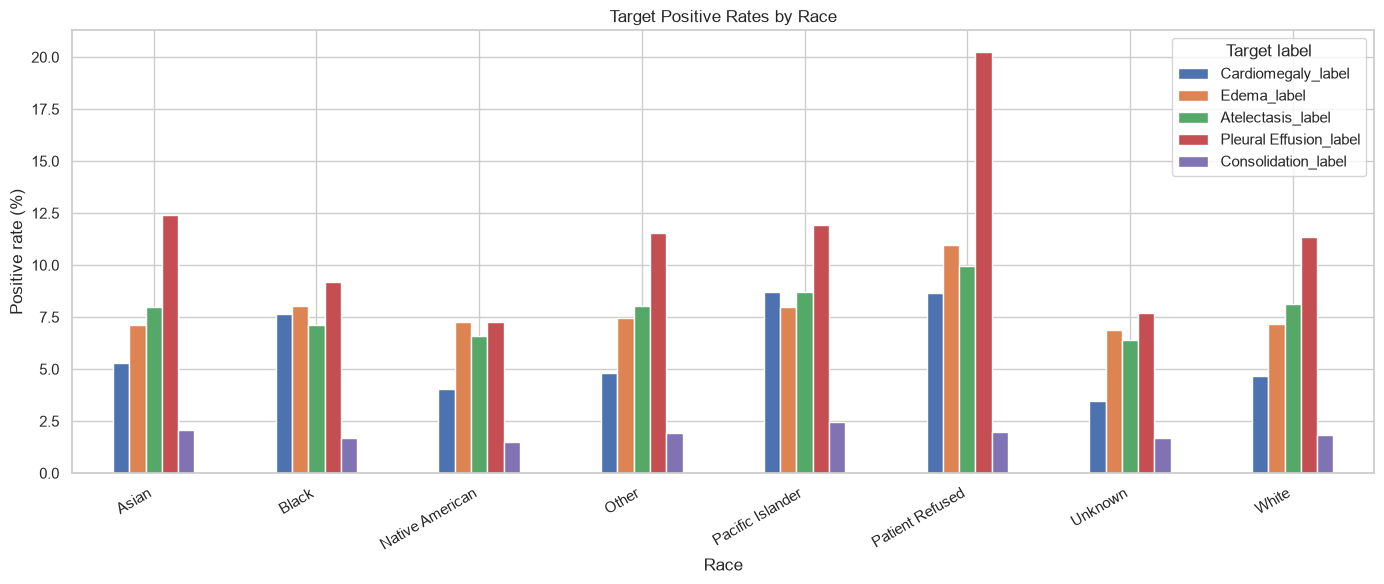

In [9]:
race_rates = df.groupby('race', dropna=False)[LABEL_COLUMNS].mean().mul(100)
race_rates.plot(kind='bar', figsize=(14, 6))
plt.title('Target Positive Rates by Race')
plt.xlabel('Race')
plt.ylabel('Positive rate (%)')
plt.xticks(rotation=30, ha='right')
plt.legend(title='Target label')
plt.tight_layout()
plt.show()

**Race breakdown summary.** Using a notable difference threshold of more than 1.5× or less than 0.5× the overall target rate, Cardiomegaly is elevated for Black (7.65%), Pacific Islander (8.68%), and Patient Refused (8.64%) rows versus 4.83% overall; Pleural Effusion is elevated for Patient Refused rows (20.27%) versus 10.95% overall. These descriptive differences do not establish a causal explanation and should be discussed as a limitation.

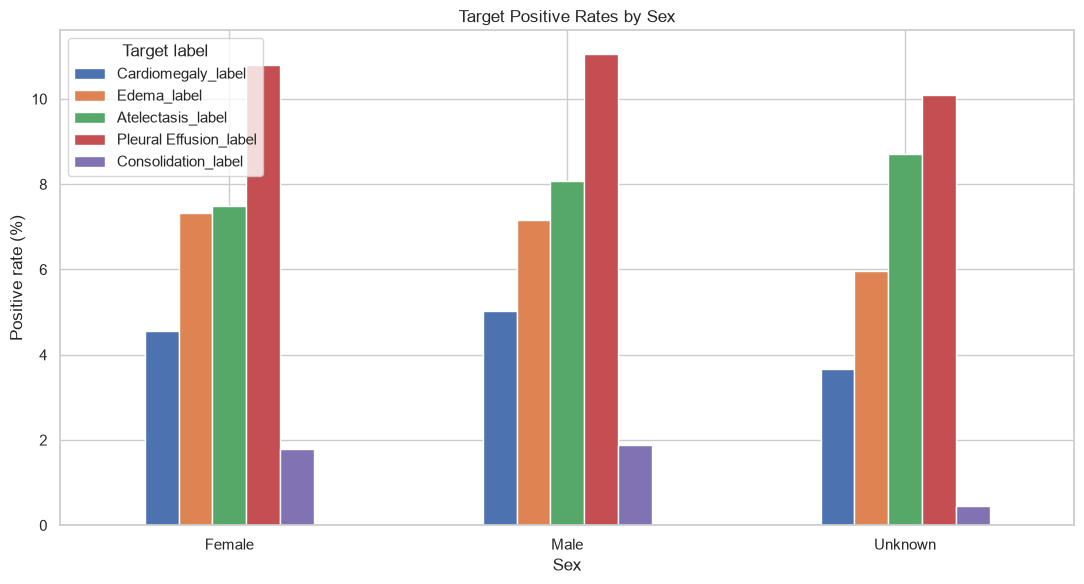

In [10]:
sex_rates = df.groupby('sex', dropna=False)[LABEL_COLUMNS].mean().mul(100)
sex_rates.plot(kind='bar', figsize=(11, 6))
plt.title('Target Positive Rates by Sex')
plt.xlabel('Sex')
plt.ylabel('Positive rate (%)')
plt.xticks(rotation=0)
plt.legend(title='Target label')
plt.tight_layout()
plt.show()

**Sex breakdown summary.** With the same 1.5×/0.5× threshold, the small Unknown-sex group has Consolidation at 0.46%, below half of the 1.84% dataset average; Female and Male rates are otherwise comparatively close. This is descriptive only, and the Unknown category has just 218 rows, so it should be interpreted cautiously in limitations reporting.

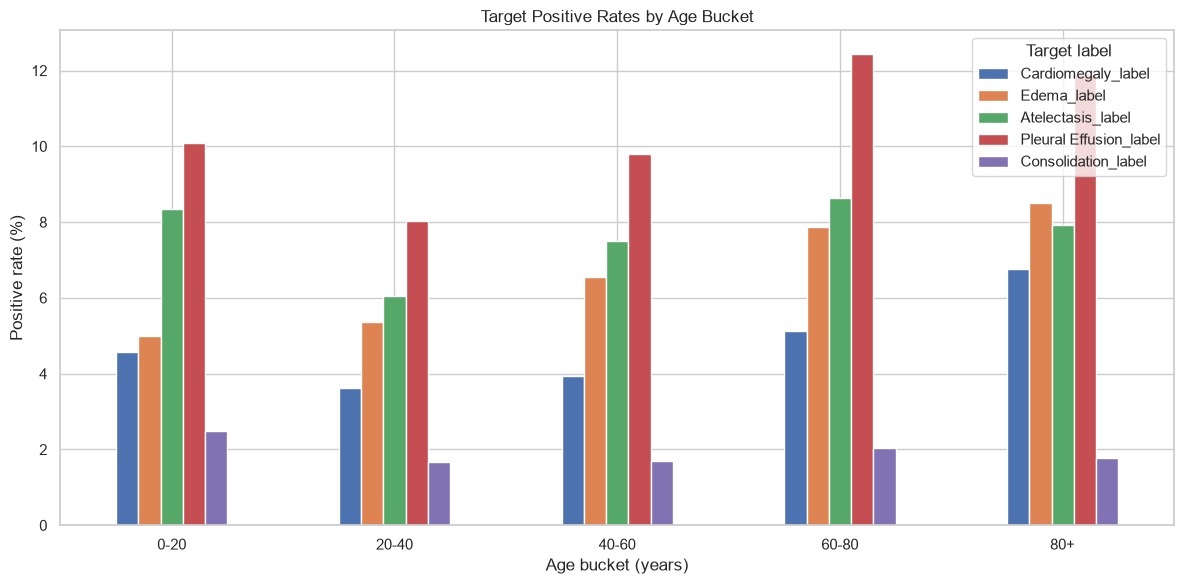

In [11]:
age_bins = [0, 20, 40, 60, 80, float('inf')]
age_labels = ['0-20', '20-40', '40-60', '60-80', '80+']
df['age_bucket_eda'] = pd.cut(df['age'], bins=age_bins, labels=age_labels, right=False)
age_rates = df.groupby('age_bucket_eda', observed=False)[LABEL_COLUMNS].mean().mul(100)
age_rates.plot(kind='bar', figsize=(12, 6))
plt.title('Target Positive Rates by Age Bucket')
plt.xlabel('Age bucket (years)')
plt.ylabel('Positive rate (%)')
plt.xticks(rotation=0)
plt.legend(title='Target label')
plt.tight_layout()
plt.show()

**Age breakdown summary.** No age bucket crosses the pre-specified 1.5×/0.5× threshold relative to its overall label rate. The largest visible age pattern is Cardiomegaly, increasing from 3.61% at ages 20–40 to 6.76% at ages 80+, which remains below the 1.5× flag threshold; no causal interpretation is made.

## Section 4: Missingness Patterns

In [12]:
bmi_missing_by_insurance = pd.crosstab(df['insurance_type'].fillna('Missing'), df['recent_bmi'].isna(), normalize='index').mul(100).rename(columns={False: 'BMI observed (%)', True: 'BMI missing (%)'})
bmi_missing_by_insurance

recent_bmi,BMI observed (%),BMI missing (%)
insurance_type,,
Medicaid,76.641656,23.358344
Medicare,81.826843,18.173157
Other,73.995333,26.004667
Private Insurance,75.773587,24.226413
Unknown,44.140051,55.859949


In [13]:
bmi_missing_by_race = pd.crosstab(df['race'].fillna('Missing'), df['recent_bmi'].isna(), normalize='index').mul(100).rename(columns={False: 'BMI observed (%)', True: 'BMI missing (%)'})
bmi_missing_by_race

recent_bmi,BMI observed (%),BMI missing (%)
race,,
Asian,84.344393,15.655607
Black,78.755915,21.244085
Native American,76.119403,23.880597
Other,83.504059,16.495941
Pacific Islander,82.072829,17.927171
Patient Refused,87.043189,12.956811
Unknown,28.148863,71.851137
White,76.320252,23.679748


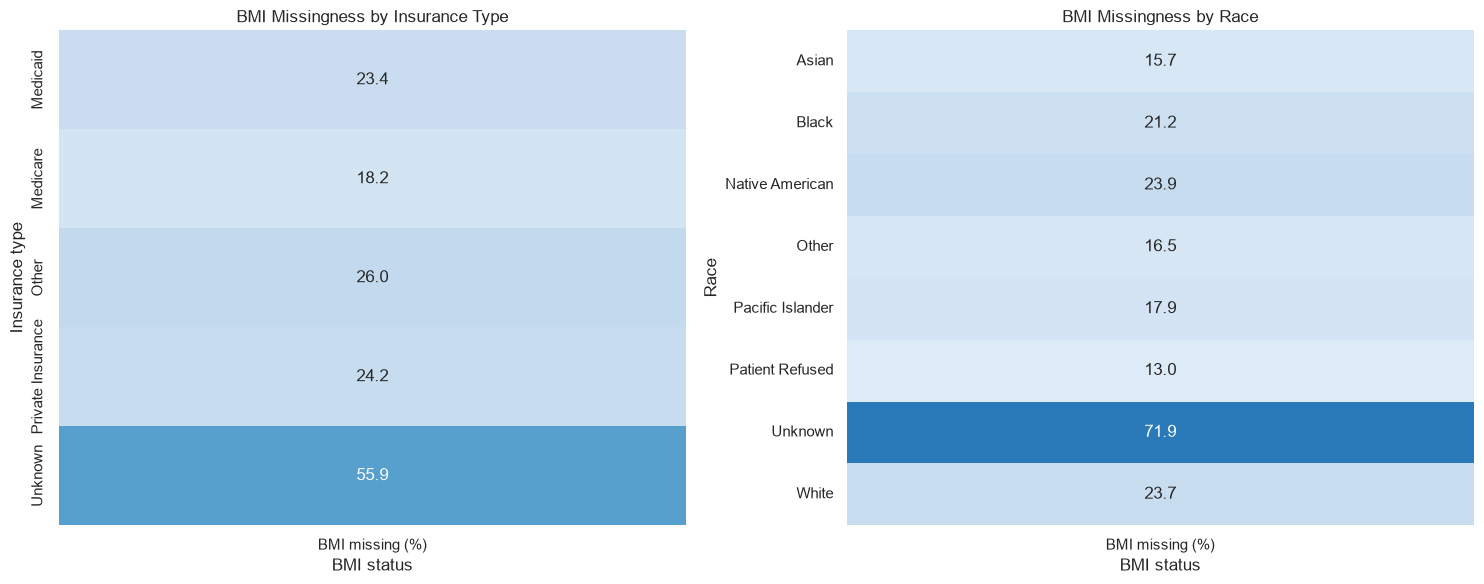

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.heatmap(bmi_missing_by_insurance[['BMI missing (%)']], annot=True, fmt='.1f', cmap='Blues', vmin=0, vmax=100, ax=axes[0], cbar=False)
axes[0].set(title='BMI Missingness by Insurance Type', xlabel='BMI status', ylabel='Insurance type')
sns.heatmap(bmi_missing_by_race[['BMI missing (%)']], annot=True, fmt='.1f', cmap='Blues', vmin=0, vmax=100, ax=axes[1], cbar=False)
axes[1].set(title='BMI Missingness by Race', xlabel='BMI status', ylabel='Race')
plt.tight_layout()
plt.show()

**Section 4 summary.** BMI missingness is patterned rather than uniform: it is 55.86% for Unknown insurance versus 18.17% for Medicare, and 71.85% for Unknown race versus 12.96% for Patient Refused race. This supports treating BMI missingness as informative for future imputation and limitations discussions, rather than assuming it is completely random.